In [1]:
import numpy as np
import pandas as pd
import pygimli as pg
from pygimli.physics import ert
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.patheffects as PathEffects
from matplotlib.patches import Polygon


In [2]:
# figure plotting preferences 

dpi = 200 # resolution
fs = 20 # fontsize

10/04/26 - 12:53:29 - pyGIMLi - INFO - Cache /Users/teddiherringnew/opt/miniconda3/envs/idgsp-mc/lib/python3.9/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (1.7s x 2): /Users/teddiherringnew/Library/Caches/pygimli/7846817088015994769
10/04/26 - 12:53:30 - pyGIMLi - INFO - Found 2 regions.
10/04/26 - 12:53:30 - pyGIMLi - INFO - Region with smallest marker (1) set to background
10/04/26 - 12:53:30 - Core - WARNING - Region Nr: 1  is background and should not get a model transformation.
10/04/26 - 12:53:30 - Core - WARNING - Region Nr: 1  is background and should not get a model control.
10/04/26 - 12:53:30 - pyGIMLi - INFO - Creating forward mesh from region infos.
10/04/26 - 12:53:30 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
10/04/26 - 12:53:30 - pyGIMLi - INFO - Use median(data values)=2401.010911957503
10/04/26 - 12:53:30 - pyGIMLi - INFO - Created startmodel from forward operator: 894 [2401.010911957503,...,2401.010911957503]




chi2 = 0.4
rms err = 2.0%


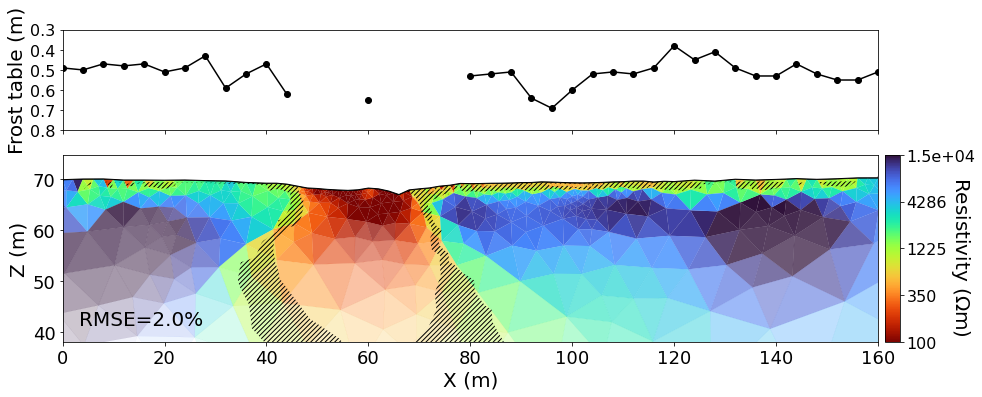

In [4]:
pn = '../formatted ert data/summer 2023/'
fn = '20230830 BURN W160.txt'
data_raw = ert.load(pn+fn) 
frost_table = pd.read_excel('../frost tables/20230830 BURN 160.xlsx')

# min/max frozen/unfrozen resistivity thresholds for each site 

levs = [580,1430]
    
# calculate geometric factor and apparent resistivity if not already in data file

if data_raw.haveData('k')==False:
        data_raw['k'] = ert.createGeometricFactors(data_raw,numerical=True) # include topo in k calculation

if data_raw.haveData('rhoa')==False:
    if data_raw.haveData('r')==False:
        data_raw['r'] = data_raw['u']/data_raw['i']
    data_raw['rhoa'] = data_raw['r']*data_raw['k'] 

# put data into pandas dataframe

df = pd.DataFrame(np.array(data_raw.dataMap(),dtype='object').T)
header = df.iloc[0]
df = df[1:] 
df.columns = header
df = df.apply(pd.Series.explode).reset_index(drop=True)

df_raw = pd.DataFrame(df)
df_raw['start_index'] = df_raw.index

mgr = ert.ERTManager(data_raw)

# inversion parameters

mgr.inv.inv.setBlockyModel(True)

data_raw['err'] = ert.estimateError(
data_raw, 
absoluteError=0.001, 
relativeError=0.03 # % noise
)

# run inversion

mod = mgr.invert(
    data_raw,
    lam=3
)

# getting lambda, chi2, rms error

chi2 = mgr.inv.inv.getChi2()
rms = np.sqrt(np.mean(((data_raw['rhoa']-mgr.inv.response)/data_raw['rhoa'])**2))*100

print('chi2 = %.1f'%chi2)
print('rms err = %.1f%%'%rms)

# figure

fig1, ax = plt.subplots(1,1,figsize=[15,5])

ax, cBar = mgr.showResult(
   mod,
    ax=ax,
    cMap='turbo_r',
    coverage=mgr.coverage(),
    cMin=100,
    cMax=15000,
    orientation='vertical',
);

# colorbar

cBar.set_label('')
cBar.ax.tick_params(labelsize=fs-4) 
cBar.ax.set_title(r'Resistivity ($\Omega$m)'+ '\n',fontsize=fs,rotation=270, y=0.02,x=4.5)

# get axis limits and trim figure automatically

Ex = np.array(data_raw.sensors()).T[0] 
Ey = np.array(data_raw.sensors()).T[1]             
xmin = min(Ex)
xmax = max(Ex)
ymin = mgr.paraDomain.yMin()
ymax = mgr.paraDomain.yMax()
trim_ymin = ymin + (ymax-ymin)/2
ax.set_ylim([trim_ymin,ymax+abs(ymax-ymin)*0.07])
ax.set_xlim([xmin,xmax])

# figure details - electrodes, rms error, axis labels

#     ax.plot(Ex,Ey,'ko',zorder=3)        
ax.text(xmin+(xmax-xmin)*0.02,trim_ymin+(ymax-trim_ymin)*0.1,'RMSE=%.1f%%'%(rms),fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)
ax.set_xlabel('X (m)',fontsize=fs)
ax.set_ylabel('Z (m)',fontsize=fs)    

# add a white patch above ground surface to hide contours 

xt = np.hstack([0,Ex,410])
yt = np.hstack([1000,Ey,1000])
P= Polygon(np.array([xt,yt]).T, facecolor = 'w',edgecolor='k',linewidth=1,zorder=2) 
ax.add_patch(P)

# add threshold contours

fn.split("-")[0]

ax.tricontourf(np.array(mgr.paraDomain.cellCenters()).T[0],np.array(
            mgr.paraDomain.cellCenters()).T[1],
               mod,
               levels=levs,
               colors='k',
               hatches=['/////'],
               alpha=0
              )


# plot frost table measurements

ft_x = np.array(frost_table['x'])
topo_x = np.array(data_raw.sensors()).T[0]

ft_z = np.array(frost_table['z'])
topo_z = np.array(data_raw.sensors()).T[1]

ft_z = np.where(ft_z==0, np.nan, ft_z) 

ax1 = fig1.add_axes([0.125,0.83,0.755,0.28])
[x,i1,i2] = np.intersect1d(ft_x,topo_x,return_indices=True)
ax1.plot(ft_x,ft_z/100,'ko-')
ax1.set_ylabel('Frost table (m)',fontsize=fs)
plt.gca().invert_yaxis()
ax1.set_xlim([xmin,xmax])
ax1.tick_params(axis='both', labelsize=fs-4)
ax1.tick_params(labelbottom=False)    
ax1.set_ylim([0.8,0.3])
ax1.set_yticks(np.arange(0.3,.81,step=0.1)) 

plt.show()

fig1.savefig('../inverted results/bu1.png',format='png',dpi=dpi,bbox_inches='tight',facecolor='w')
